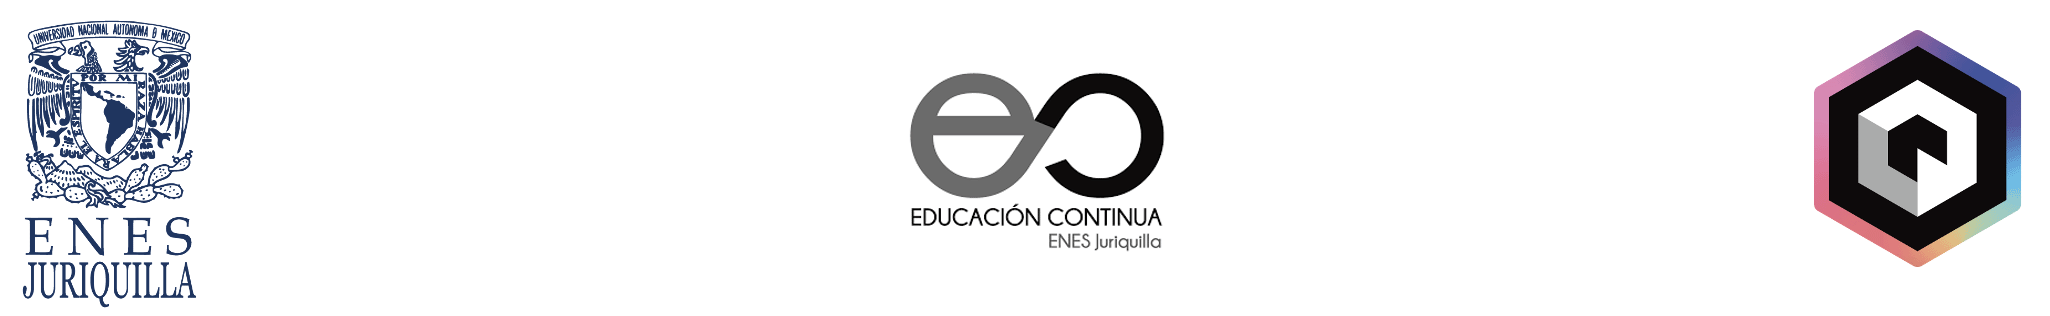





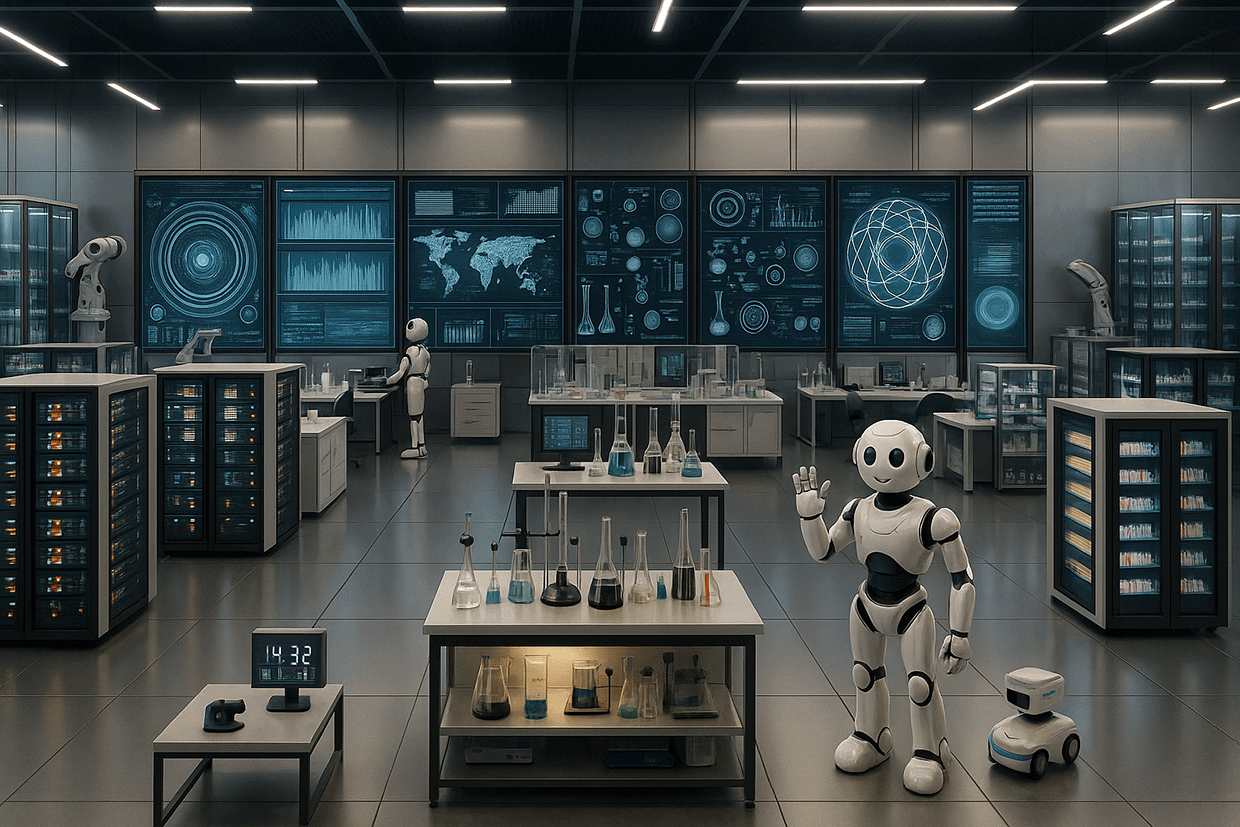

# Inteligencia Artificial - Redes Neuronales Recurrentes
## Generación de siguiente número en una secuencia numérica
### Autor: Ulises Olivares Pinto
### 12 de mayo de 2025



# Ejemplo Básico de SimpleRNN

Este notebook presenta un ejemplo básico del uso de una Red Neuronal Recurrente Simple (SimpleRNN) con Keras para procesar secuencias de datos. El objetivo es mostrar cómo se puede configurar y entrenar una SimpleRNN para predecir el siguiente número en una secuencia numérica simple.
    

In [1]:

import numpy as np
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense


In [2]:

# Generar datos de ejemplo
X = np.array([  [0, 1, 2],
                [1, 2, 3],
                [2, 3, 4],
                [3, 4, 5]])  # Ejemplos de entrada
y = np.array([3, 4, 5, 6])  # Las etiquetas (el siguiente número en la secuencia)




In [3]:
# Filas Columnas [F, index =0][C, index = 1]


print(X.shape)


(4, 3)


In [4]:
# Cambiar el tamaño de X a [muestras, pasos de tiempo, características] requerido por SimpleRNN
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(X.shape)
print(X)

(4, 3, 1)
[[[0]
  [1]
  [2]]

 [[1]
  [2]
  [3]]

 [[2]
  [3]
  [4]]

 [[3]
  [4]
  [5]]]


In [5]:

# Definir el modelo
model = Sequential()
model.add(SimpleRNN(units=256, activation='relu', input_shape=(X.shape[1], 1)))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 256)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,305 (259.00 KB)

 Trainable params: 66,305 (259.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:

model.fit(X, y, epochs=100, verbose=1)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 25.6278
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 22.4439
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 19.6319
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 17.0833
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 14.7921
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 12.6409
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 10.6081
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 8.7147
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.0240
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 5.4961
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.1490
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.0051
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.0954
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.4414
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.0617
Epoch 16/100
1

In [7]:

# Predicción para una nueva secuencia
test_input = np.array([300,400,500])
test_input = test_input.reshape((1, 3, 1))  # Cambiar el tamaño a [1, pasos de tiempo, características]
predicted_number = model.predict(test_input, verbose=1)
print(predicted_number)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[531.23035]]
